# Tendencia e decomposicao

**Objetivo:** separar a serie observada em componentes mais interpretaveis para responder duas perguntas centrais:
- existe crescimento ou queda estrutural ao longo do tempo?
- o padrao sazonal parece estavel ou muda bastante entre os anos?

Como a serie e diaria e ja mostrou padroes de calendario semanais e anuais, vamos priorizar uma decomposicao do tipo **MSTL** quando ela estiver disponivel no ambiente. Esse metodo permite decompor a serie em:
- tendencia de longo prazo;
- sazonalidade semanal;
- sazonalidade anual;
- residuo, que representa a parte nao explicada pelos componentes anteriores.

Se o `MSTL` nao estiver disponivel, o codigo cai automaticamente para uma decomposicao `STL` semanal, para manter a secao executavel.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [10]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [11]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Tendencia e decomposicao

In [12]:
# Preparamos a serie diaria com indice temporal regular.
serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2008-01-01,79
2008-01-02,46
2008-01-03,53
2008-01-04,46
2008-01-05,42


### Ajuste da decomposicao

Nesta etapa o modelo separa a serie em tendencia, sazonalidade e residuo. No caso do `MSTL`, teremos duas sazonalidades explicitas: uma de **7 dias** e outra de **365 dias**.

In [13]:
if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

print("Periodos sazonais considerados:", periodos_decomposicao)
display(df_decomp.head().round(2))

Periodos sazonais considerados: (7, 365)


,observado,tendencia,sazonal_7,sazonal_365,sazonal_total,residuo,ano,mes,mes_nome,dia_semana_num,dia_semana_nome
data_dia,,,,,,,,,,,
2008-01-01,79.0,57.53,4.22,-46.41,-42.19,63.67,2008,1,Jan,1,Ter
2008-01-02,46.0,57.53,4.21,-21.18,-16.96,5.44,2008,1,Jan,2,Qua
2008-01-03,53.0,57.52,8.59,-11.93,-3.34,-1.19,2008,1,Jan,3,Qui
2008-01-04,46.0,57.52,4.38,-16.95,-12.57,1.04,2008,1,Jan,4,Sex
2008-01-05,42.0,57.52,-4.06,-15.67,-19.72,4.20,2008,1,Jan,5,Sab


### Visualizacao dos componentes

O objetivo aqui e comparar visualmente a serie observada com a tendencia estimada, ver o comportamento das sazonalidades e inspecionar o residuo. Se o residuo ainda tiver muitos blocos estruturados, isso pode ser sinal de que existem eventos ou quebras que a decomposicao nao capturou.

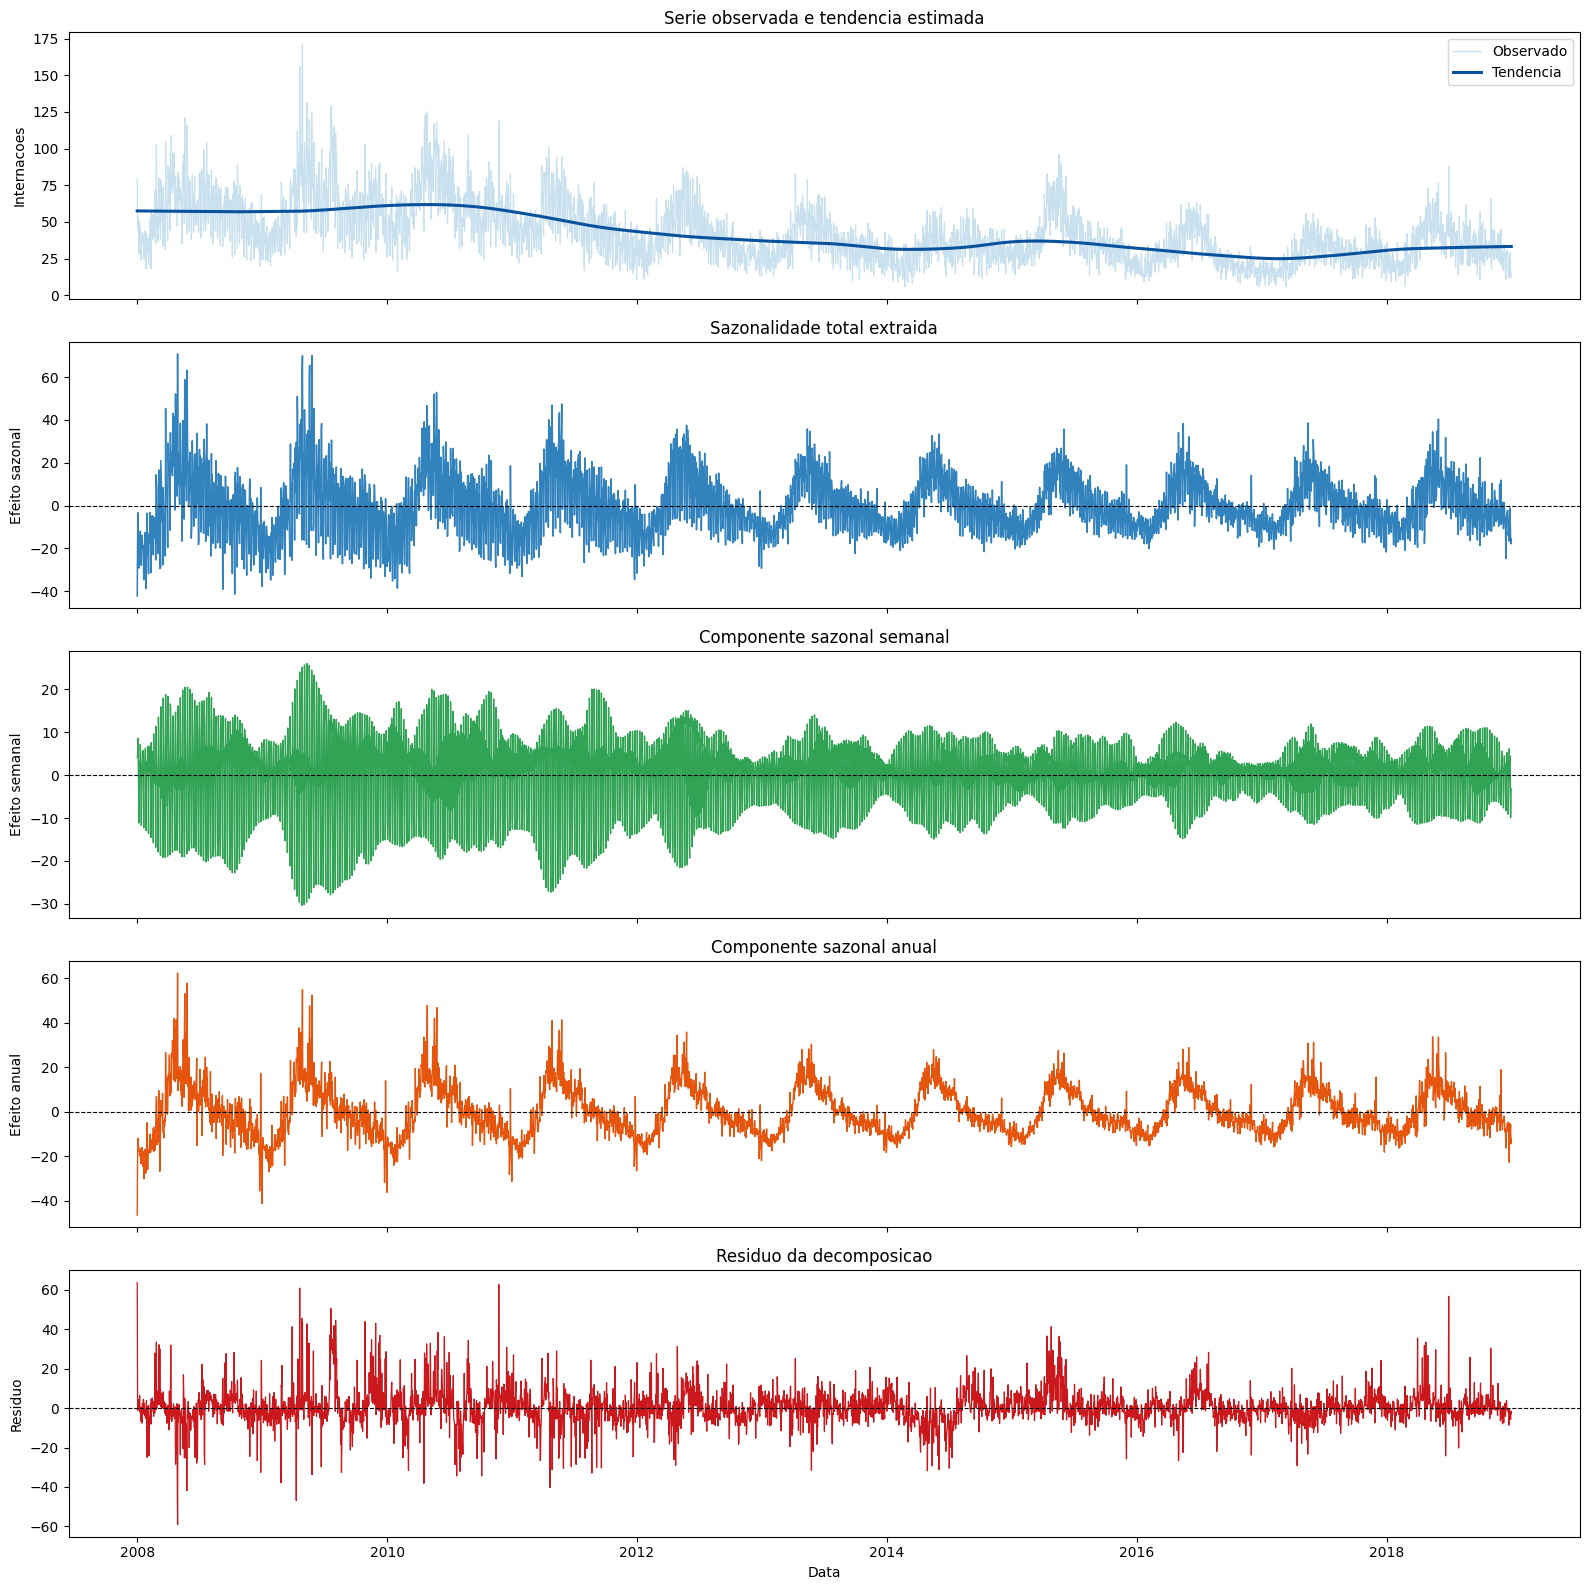

In [14]:
tem_sazonal_anual = df_decomp["sazonal_365"].notna().any()
n_linhas = 5 if tem_sazonal_anual else 4

fig, axes = plt.subplots(n_linhas, 1, figsize=(16, 3.2 * n_linhas), sharex=True)

axes[0].plot(df_decomp.index, df_decomp["observado"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Observado")
axes[0].plot(df_decomp.index, df_decomp["tendencia"], color="#08519c", linewidth=2.2, label="Tendencia")
axes[0].set_title("Serie observada e tendencia estimada")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_decomp.index, df_decomp["sazonal_total"], color="#3182bd", linewidth=1.1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Sazonalidade total extraida")
axes[1].set_ylabel("Efeito sazonal")

axes[2].plot(df_decomp.index, df_decomp["sazonal_7"], color="#31a354", linewidth=1.0)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Componente sazonal semanal")
axes[2].set_ylabel("Efeito semanal")

if tem_sazonal_anual:
    axes[3].plot(df_decomp.index, df_decomp["sazonal_365"], color="#e6550d", linewidth=1.0)
    axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_title("Componente sazonal anual")
    axes[3].set_ylabel("Efeito anual")
    eixo_residuo = axes[4]
else:
    eixo_residuo = axes[3]

eixo_residuo.plot(df_decomp.index, df_decomp["residuo"], color="#cb181d", linewidth=0.9)
eixo_residuo.axhline(0, color="black", linestyle="--", linewidth=0.8)
eixo_residuo.set_title("Residuo da decomposicao")
eixo_residuo.set_ylabel("Residuo")
eixo_residuo.set_xlabel("Data")

plt.tight_layout()
plt.show()

### Resumo quantitativo da tendencia e dos componentes

Aqui resumimos numericamente o comportamento da tendencia e a intensidade relativa dos componentes. O uso do intervalo entre os percentis 5 e 95 ajuda a medir amplitude de forma menos sensivel a pontos extremos.

In [15]:
serie_tendencia_valida = df_decomp["tendencia"].dropna()
data_inicio_tendencia = serie_tendencia_valida.index.min()
data_fim_tendencia = serie_tendencia_valida.index.max()
tendencia_inicial = serie_tendencia_valida.iloc[0]
tendencia_final = serie_tendencia_valida.iloc[-1]
variacao_tendencia_abs = tendencia_final - tendencia_inicial
variacao_tendencia_pct = (tendencia_final / tendencia_inicial - 1) * 100 if tendencia_inicial != 0 else np.nan
data_pico_tendencia = serie_tendencia_valida.idxmax()
data_vale_tendencia = serie_tendencia_valida.idxmin()

colunas_componentes = ["tendencia", "sazonal_total", "sazonal_7", "residuo"]
if tem_sazonal_anual:
    colunas_componentes.insert(3, "sazonal_365")

resumo_componentes = pd.DataFrame(
    {
        "componente": colunas_componentes,
        "media": [df_decomp[col].mean() for col in colunas_componentes],
        "desvio_padrao": [df_decomp[col].std() for col in colunas_componentes],
        "amplitude_p5_p95": [df_decomp[col].quantile(0.95) - df_decomp[col].quantile(0.05) for col in colunas_componentes],
    }
)

perfil_tendencia_anual = (
    df_decomp.groupby("ano")["tendencia"]
    .mean()
    .reset_index()
)

display(resumo_componentes.round(2))
display(perfil_tendencia_anual.round(2))

print(f"Inicio da tendencia estimada: {data_inicio_tendencia.date()} -> {tendencia_inicial:.2f}")
print(f"Fim da tendencia estimada: {data_fim_tendencia.date()} -> {tendencia_final:.2f}")
print(f"Variacao absoluta da tendencia: {variacao_tendencia_abs:.2f}")
print(f"Variacao percentual da tendencia: {variacao_tendencia_pct:.2f}%")
print(f"Maior nivel de tendencia em: {data_pico_tendencia.date()} -> {serie_tendencia_valida.max():.2f}")
print(f"Menor nivel de tendencia em: {data_vale_tendencia.date()} -> {serie_tendencia_valida.min():.2f}")

,componente,media,desvio_padrao,amplitude_p5_p95
0,tendencia,41.57,12.20,35.27
1,sazonal_total,0.02,13.90,43.89
2,sazonal_7,0.00,8.37,27.09
3,sazonal_365,0.02,11.06,33.87
4,residuo,0.45,9.01,25.77


,ano,tendencia
0,2008,57.21
1,2009,58.57
2,2010,60.74
3,2011,49.77
4,2012,39.83
5,2013,35.02
6,2014,32.81
7,2015,35.45
8,2016,28.46
9,2017,27.03


Inicio da tendencia estimada: 2008-01-01 -> 57.53
Fim da tendencia estimada: 2018-12-31 -> 33.31
Variacao absoluta da tendencia: -24.22
Variacao percentual da tendencia: -42.10%
Maior nivel de tendencia em: 2010-05-01 -> 61.87
Menor nivel de tendencia em: 2017-02-21 -> 24.98


### Estabilidade do padrao sazonal

Agora usamos os componentes extraidos para verificar se o padrao semanal e anual permanece parecido ao longo do tempo. Isso e importante porque uma serie pode ter sazonalidade forte, mas instavel, o que muda bastante a estrategia de modelagem.

,dia_semana_nome,sazonal_7
0,Seg,7.61
1,Ter,5.85
2,Qua,4.05
3,Qui,2.31
4,Sex,1.45
5,Sab,-9.31
6,Dom,-11.96


,ano,amplitude_tendencia,amplitude_sazonal_semanal,volatilidade_residuo,amplitude_sazonal_anual
0,2008,0.52,35.02,10.32,46.63
1,2009,3.82,42.49,13.31,42.39
2,2010,4.10,33.80,11.22,38.71
3,2011,12.47,32.58,9.27,35.59
4,2012,5.63,28.26,7.94,33.07
5,2013,4.84,21.33,6.46,30.85
6,2014,4.74,21.30,8.52,29.47
7,2015,4.51,18.74,8.08,28.30
8,2016,6.28,15.11,6.79,26.96
9,2017,5.33,16.68,5.99,27.17


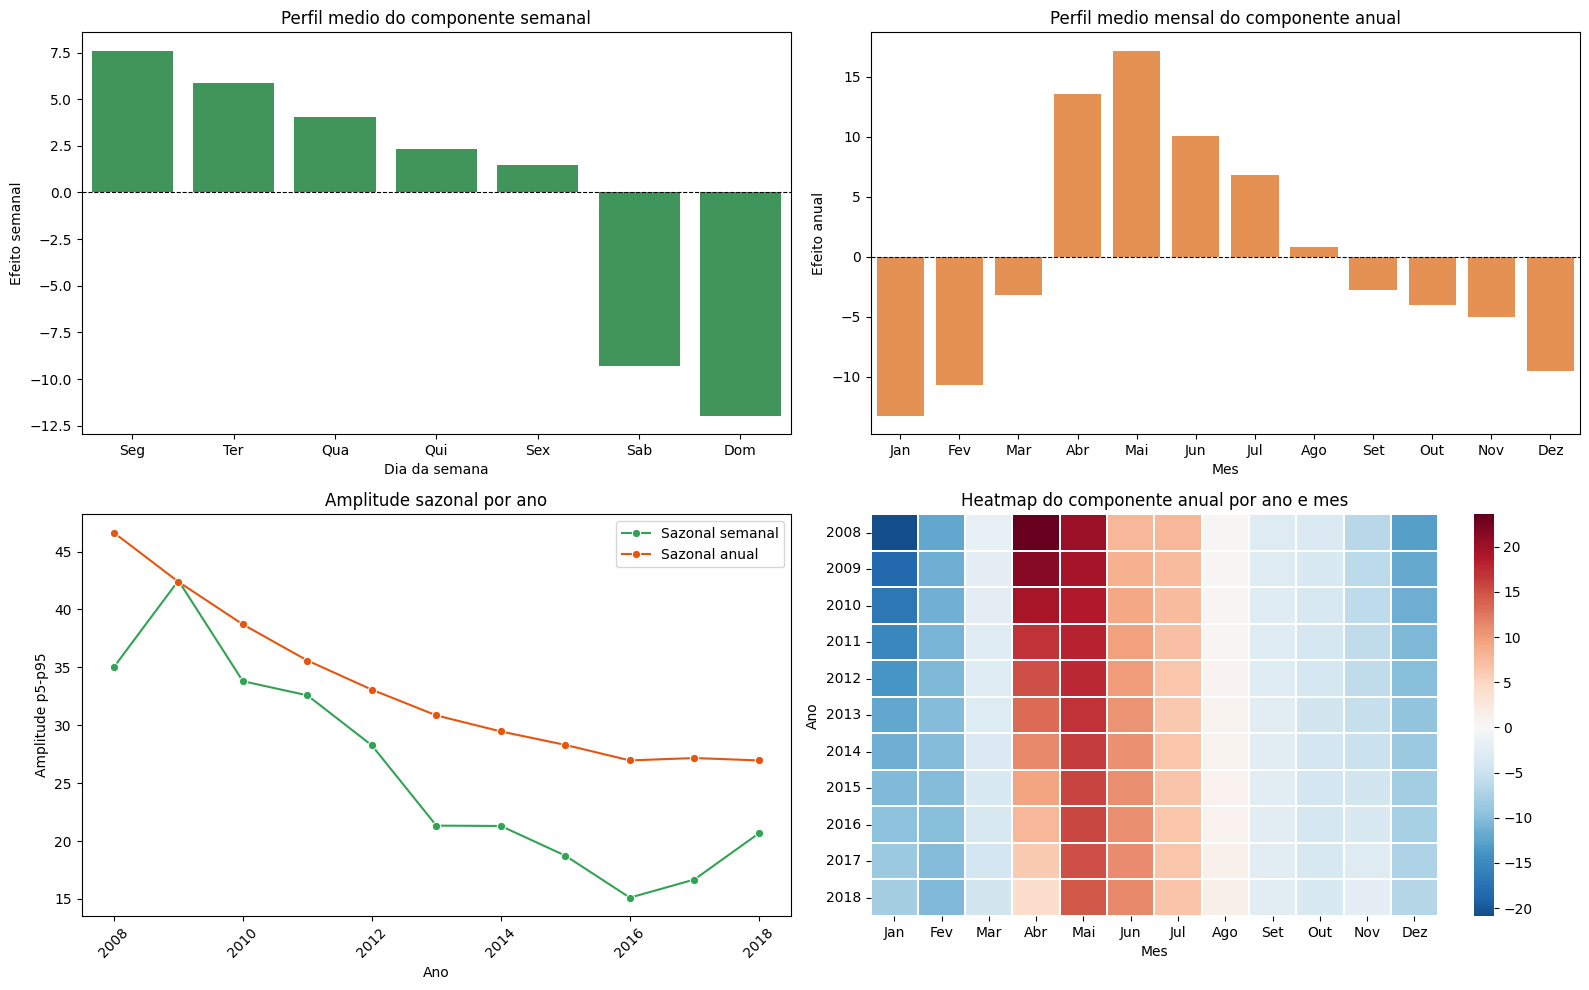

In [16]:
perfil_sazonal_semanal = (
    df_decomp.groupby(["dia_semana_num", "dia_semana_nome"], observed=True)["sazonal_7"]
    .mean()
    .reset_index()
    .sort_values("dia_semana_num")
)

amplitude_por_ano = (
    df_decomp.groupby("ano")
    .agg(
        amplitude_tendencia=("tendencia", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        amplitude_sazonal_semanal=("sazonal_7", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        volatilidade_residuo=("residuo", "std"),
    )
    .reset_index()
)

display(perfil_sazonal_semanal[["dia_semana_nome", "sazonal_7"]].round(2))

if tem_sazonal_anual:
    perfil_sazonal_anual_mensal = (
        df_decomp.groupby(["mes", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .sort_values("mes")
    )

    amplitude_sazonal_anual = (
        df_decomp.groupby("ano")["sazonal_365"]
        .apply(lambda s: s.quantile(0.95) - s.quantile(0.05))
        .rename("amplitude_sazonal_anual")
        .reset_index()
    )

    amplitude_por_ano = amplitude_por_ano.merge(amplitude_sazonal_anual, on="ano", how="left")

    heatmap_sazonal_anual = (
        df_decomp.groupby(["ano", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .pivot(index="ano", columns="mes_nome", values="sazonal_365")
        .reindex(columns=list(meses.values()))
    )

    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Perfil medio do componente semanal")
    axes[0, 0].set_xlabel("Dia da semana")
    axes[0, 0].set_ylabel("Efeito semanal")

    sns.barplot(data=perfil_sazonal_anual_mensal, x="mes_nome", y="sazonal_365", color="#fd8d3c", ax=axes[0, 1])
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 1].set_title("Perfil medio mensal do componente anual")
    axes[0, 1].set_xlabel("Mes")
    axes[0, 1].set_ylabel("Efeito anual")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", label="Sazonal semanal", ax=axes[1, 0])
    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_anual", marker="o", color="#e6550d", label="Sazonal anual", ax=axes[1, 0])
    axes[1, 0].set_title("Amplitude sazonal por ano")
    axes[1, 0].set_xlabel("Ano")
    axes[1, 0].set_ylabel("Amplitude p5-p95")
    axes[1, 0].tick_params(axis="x", rotation=45)

    sns.heatmap(heatmap_sazonal_anual, cmap="RdBu_r", center=0, linewidths=0.1, ax=axes[1, 1])
    axes[1, 1].set_title("Heatmap do componente anual por ano e mes")
    axes[1, 1].set_xlabel("Mes")
    axes[1, 1].set_ylabel("Ano")

    plt.tight_layout()
    plt.show()
else:
    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0].set_title("Perfil medio do componente semanal")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Efeito semanal")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", ax=axes[1])
    axes[1].set_title("Amplitude semanal por ano")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Amplitude p5-p95")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### Resumo interpretativo dos resultados

A decomposição por **MSTL** mostrou novamente uma combinação de **queda estrutural de longo prazo** com **sazonalidades semanal e anual bem marcadas**. A tendência estimada saiu de **605,4 internações** no início da série (**2012-01-01**) para **242,6** no fim (**2018-12-31**), queda de aproximadamente **59,9%**. Isso reforça que a série bruta não é estacionária em nível e que houve mudança estrutural forte no período.

Na tendência média por ano, a trajetória permanece descendente de **2012 (548,8)** até **2017 (239,5)**, com reduções mais suaves em **2014-2015** e uma **recomposição moderada em 2018 (251,3)**. Ou seja, além da sazonalidade, há mudanças de nível relevantes e não lineares ao longo dos anos.

A componente semanal seguiu coerente com a análise de calendário: efeito **positivo** em **segunda (+63,0)**, **terça (+40,3)** e **quarta (+53,2)**, leve em **quinta (+11,3)** e **sexta (+12,4)**, e **negativo no fim de semana**, sobretudo **domingo (-98,3)** e **sábado (-81,8)**. Isso indica um ciclo semanal robusto e relativamente estável.

A componente anual também permaneceu relevante, com **amplitude p5-p95 de 355,4**. Assim, a elevação observada no outono-início do inverno não parece ser apenas reflexo da tendência, mas parte de um padrão sazonal anual recorrente.

Na comparação de intensidade dos componentes, a maior amplitude estrutural foi da **sazonalidade total (427,7)**, seguida da **sazonalidade anual (355,4)**, da **tendência (330,4)** e da **sazonalidade semanal (238,5)**. O **resíduo** ainda manteve amplitude alta (**279,8**), sugerindo variação não explicada pela decomposição e possíveis eventos fora do padrão regular.

As amplitudes também mudaram ao longo do tempo. Em **2012**, a amplitude semanal foi **378,4** e a anual **495,7**; em **2017**, caem para **144,1** e **251,8**; em **2018**, ficam em **150,3** e **255,6**. A volatilidade do resíduo também foi maior nos anos iniciais/intermediários (**2012: 108,9; 2014: 103,5; 2015: 100,7**) e menor nos anos recentes (**2017: 51,8; 2018: 60,1**).

**Possíveis análises e consequências**
- A queda estrutural da tendência indica necessidade de tratar não estacionariedade antes de modelos estatísticos clássicos.
- A sazonalidade semanal segue forte e deve entrar como componente determinística ou feature obrigatória de calendário.
- A sazonalidade anual continua relevante, reforçando o uso de variáveis sazonais/climáticas no período de outono-inverno.
- O resíduo ainda expressivo sugere investigar janelas anômalas e possíveis quebras de regime antes da modelagem final.
- Como as amplitudes mudam no tempo, vale testar abordagens robustas a mudança de regime e validação temporal por blocos.